# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: _<your name>_
* Student ID: _<your id>_


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

**Use of Generative AI**
* A Gen AI assistant was used to help with code structure, debugging, and explanations of concepts. All code and outputs were reviewed, tested, and understood by me, and the analysis and decisions are my own.

# Libraries

In [10]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

# 1. Business Understanding

**Goal:** Predict a car's manufacturer suggested retail price (`Trim Msrp`) from its specifications, to power a fair-price estimation tool for a car marketplace / dealership.

**Task type:** Regression (the target is a continuous dollar value).

**Target column:** `Trim Msrp` (USD).

# 2. Data Understanding

## 2.1 Load dataset

In [12]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "data/MLDP-C25U02-Apr2026/data/v1-legacy-carapi-datafeed-sample.csv"
df = pd.read_csv(FILE_PATH)

print("Rows, columns:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/MLDP-C25U02-Apr2026/data/v1-legacy-carapi-datafeed-sample.csv'

## 2.2 Summary Statistics

In [ ]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17707 entries, 0 to 17706
Data columns (total 57 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Make Id                                      17707 non-null  int64  
 1   Make Name                                    17707 non-null  object 
 2   Model Id                                     17707 non-null  int64  
 3   Model Name                                   17707 non-null  object 
 4   Trim Id                                      17707 non-null  int64  
 5   Trim Year                                    17707 non-null  int64  
 6   Trim Name                                    17707 non-null  object 
 7   Trim Description                             17707 non-null  object 
 8   Trim Msrp                                    17707 non-null  int64  
 9   Trim Invoice                                 17704 non-null  float64
 10

In [ ]:
## Describe data distribution
df.describe(include="all")

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
count,17707.000000,17707,17707.000000,17707,17707.000000,17707.000000,17707,17707,1.770700e+04,17704.000000,...,14565.000000,17449.000000,17449.000000,462.000000,389.000000,389.000000,325.000000,299.000000,316.000000,161.000000
unique,NaN,46,NaN,549,NaN,NaN,1809,6809,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ford,NaN,1500,NaN,NaN,Base,xDrive28i 4dr SUV AWD (2.0L 4cyl Turbo 8A),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1868,NaN,410,NaN,NaN,914,16,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,20.042413,NaN,275.892133,NaN,15329.854916,2017.514655,NaN,NaN,4.854835e+04,39881.853479,...,27.946447,305.924867,413.428678,89.807359,96.192802,87.591260,106.766154,40.301003,5.139241,48.639752
std,12.748010,NaN,209.868165,NaN,6538.017344,1.694286,NaN,NaN,4.408983e+04,25761.988991,...,6.673848,156.765174,208.121077,25.288781,29.979226,21.410929,113.190790,13.686925,3.551192,29.401861
min,1.000000,NaN,2.000000,NaN,6292.000000,2015.000000,NaN,NaN,0.000000e+00,0.000000,...,11.000000,0.000000,0.000000,39.000000,34.000000,37.000000,9.000000,24.000000,1.300000,1.000000
25%,8.000000,NaN,167.000000,NaN,10718.500000,2016.000000,NaN,NaN,3.048000e+04,27235.750000,...,23.000000,296.000000,406.000000,68.000000,68.000000,70.000000,19.000000,30.000000,2.700000,25.000000
50%,19.000000,NaN,267.000000,NaN,15145.000000,2018.000000,NaN,NaN,3.933500e+04,35931.500000,...,27.000000,348.000000,475.000000,97.000000,101.000000,93.000000,32.000000,33.000000,3.000000,38.000000
75%,29.000000,NaN,379.000000,NaN,19572.500000,2019.000000,NaN,NaN,5.104500e+04,46011.000000,...,32.000000,391.000000,537.000000,110.000000,124.000000,103.000000,215.000000,49.000000,8.125000,75.000000


In [ ]:
## Check for missing data (percentage missing per column, high to low)
(df.isna().mean().sort_values(ascending=False) * 100).round(1)

Mileage Battery Capacity Electric              99.1
Mileage Epa Kwh 100 Mi Electric                98.3
Mileage Epa Time To Charge Hr 240v Electric    98.2
Mileage Range Electric                         98.2
Body Rear Track                                98.1
Body Front Track                               98.1
Mileage Epa City Mpg Electric                  97.8
Mileage Epa Highway Mpg Electric               97.8
Mileage Epa Combined Mpg Electric              97.4
Body Max Cargo Capacity                        50.3
Body Max Payload                               48.3
Body Max Towing Capacity                       45.5
Body Gross Weight                              38.8
Body Ground Clearance                          34.7
Body Cargo Capacity                            28.4
Mileage Epa Highway Mpg                        17.7
Mileage Epa City Mpg                           17.7
Mileage Combined Mpg                           17.4
Body Curb Weight                               11.2
Engine Valve

**Missingness — three tiers:**
- **Drop (>97% empty):** the 7 electric-vehicle columns + `Body Front Track` / `Body Rear Track`. Almost no signal.
- **Decide (28–50% empty):** `Body Max Cargo Capacity`, `Body Max Payload`, `Body Max Towing Capacity`, `Body Gross Weight`, `Body Ground Clearance`, `Body Cargo Capacity`. These are missing largely because they don't apply to non-truck body types — i.e. closer to 'not applicable' than missing at random.
- **Impute (<20% empty):** remaining small gaps — fill with median (numeric) / mode (categorical) in cleaning.

In [ ]:
## Inspect the odd text column: Engine Cylinders
df["Engine Cylinders"].value_counts()

Engine Cylinders
I4        6409
V6        5417
V8        4431
flat 4     353
I6         293
flat 6     150
V12        143
I3         118
V10         57
W12         37
I5          34
I2           9
W16          1
Name: count, dtype: int64

`Engine Cylinders` is stored as **text combining engine layout + cylinder count** (e.g. `I4`, `V6`, `V8`, `flat 4`, `W16`). In feature engineering this can be split into a **numeric cylinder count** (I4 → 4, V8 → 8, W16 → 16) and a **categorical configuration** (I / V / flat / W).

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

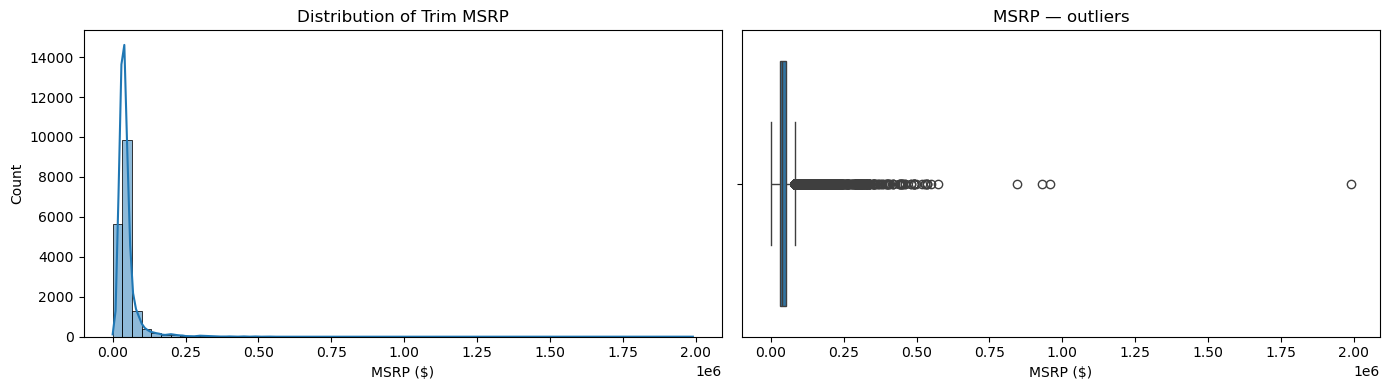

count    1.770700e+04
mean     4.854835e+04
std      4.408983e+04
min      0.000000e+00
25%      3.048000e+04
50%      3.933500e+04
75%      5.104500e+04
max      1.990064e+06
Name: Trim Msrp, dtype: float64


In [ ]:
## Understanding distribution of target (Trim Msrp)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Trim Msrp"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Trim MSRP")
axes[0].set_xlabel("MSRP ($)")

sns.boxplot(x=df["Trim Msrp"], ax=axes[1])
axes[1].set_title("MSRP — outliers")
axes[1].set_xlabel("MSRP ($)")

plt.tight_layout()
plt.show()

print(df["Trim Msrp"].describe())

MSRP is **heavily right-skewed**: mean (~\$48.5k) ≫ median (~\$39.3k). A long tail of exotics reaches ~\$2M and some rows are \$0.

**Implications for modelling:** (1) filter the \$0 rows and extreme high-end outliers in cleaning; (2) the skew favours a tree-based model and/or a log-transformed target.

### 2.3.1.2 Understanding distribution of features

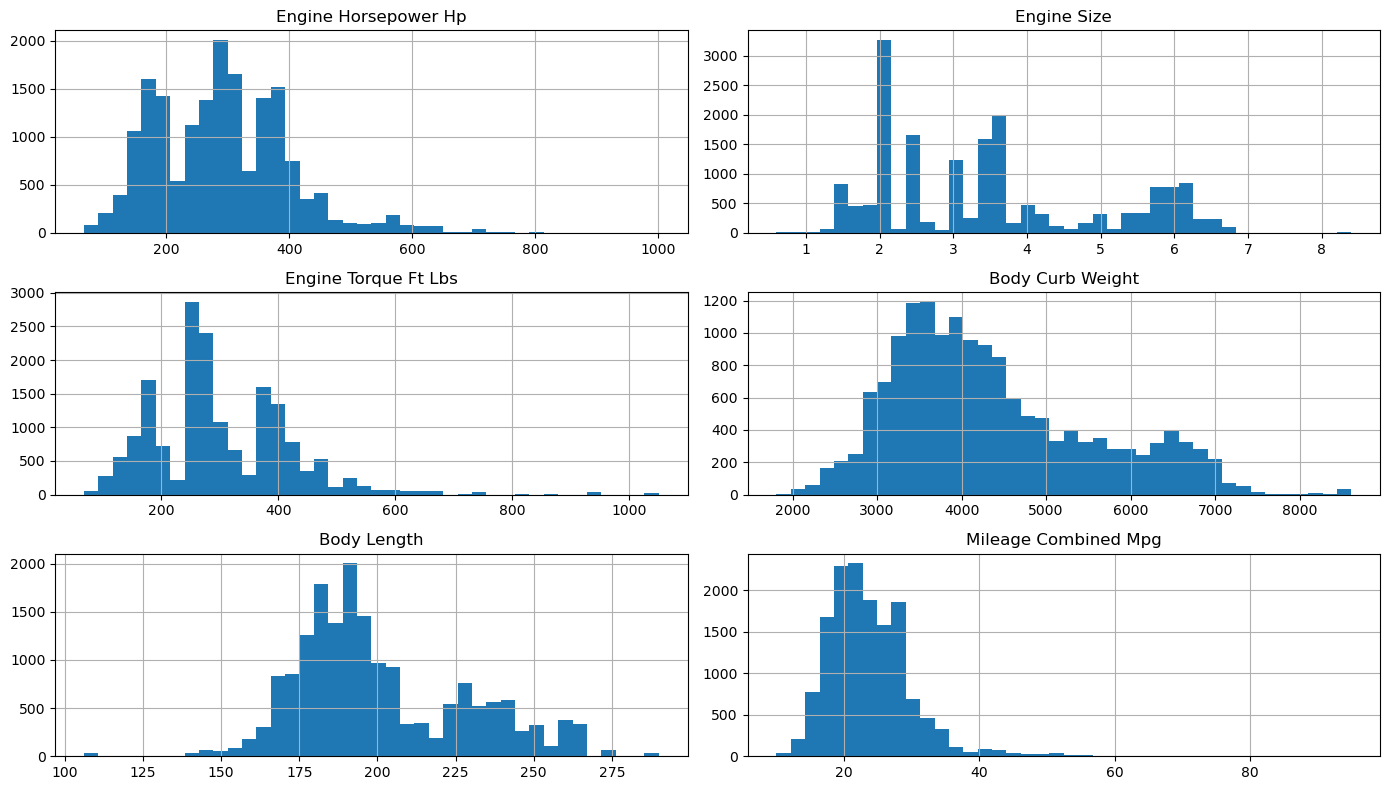

In [ ]:
## Understanding distribution of key numeric features
num_features = ["Engine Horsepower Hp", "Engine Size", "Engine Torque Ft Lbs",
                "Body Curb Weight", "Body Length", "Mileage Combined Mpg"]

df[num_features].hist(bins=40, figsize=(14, 8))
plt.tight_layout()
plt.show()

### 2.3.2 Understanding relationship between variables

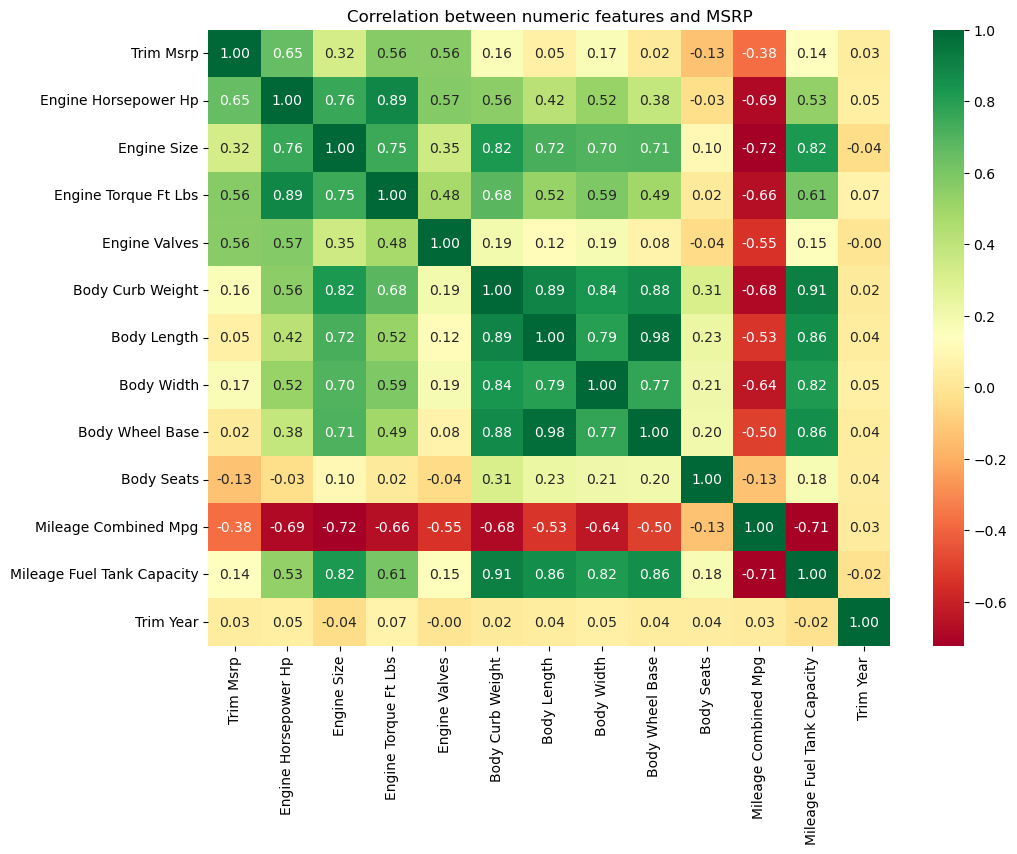

In [ ]:
## Correlation between numeric features and MSRP
corr_cols = ["Trim Msrp", "Engine Horsepower Hp", "Engine Size", "Engine Torque Ft Lbs",
             "Engine Valves", "Body Curb Weight", "Body Length", "Body Width",
             "Body Wheel Base", "Body Seats", "Mileage Combined Mpg",
             "Mileage Fuel Tank Capacity", "Trim Year"]

plt.figure(figsize=(11, 8))
sns.heatmap(df[corr_cols].corr(), cmap="RdYlGn", annot=True, fmt=".2f")
plt.title("Correlation between numeric features and MSRP")
plt.show()

**Key findings (top row — correlation with MSRP):**
- **Power drives price:** Horsepower 0.65, Torque 0.56, Valves 0.56.
- **Size does not:** Curb Weight 0.16, Body Length 0.05, Wheel Base 0.02 — a heavy truck can be cheap while a light sports car is expensive, so raw size roughly cancels out.
- **Efficiency is negative:** Combined MPG −0.38 (more powerful cars are thirstier and pricier).
- **`Trim Year` ≈ 0.03** — no signal in a 2015–2020 snapshot.

**Multicollinearity is strong:** Body Length ↔ Wheel Base 0.98, Curb Weight ↔ Fuel Tank 0.91, Horsepower ↔ Torque 0.89. This destabilises linear-model coefficients and justifies feature selection and/or preferring a tree-based model.

C:\Users\manfr\AppData\Local\Temp\ipykernel_17736\4018220295.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), ha="right")


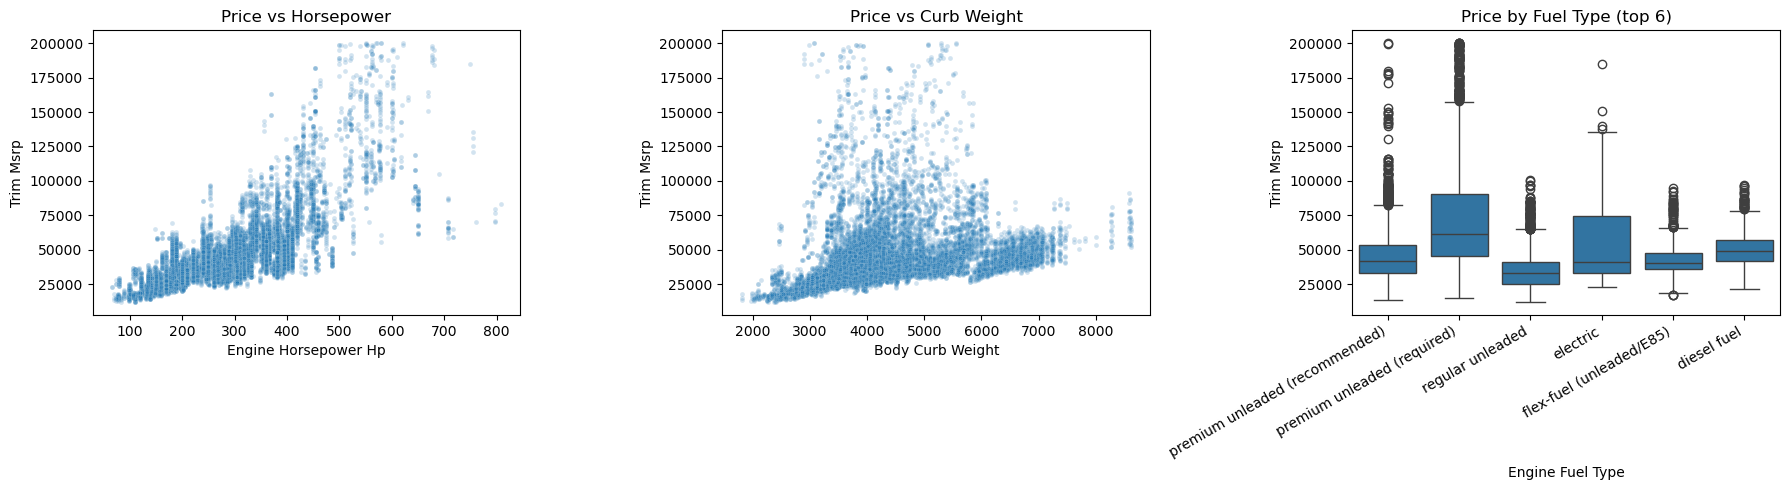

In [ ]:
## Target vs key features (zoomed to $1k-$200k so the bulk of the data is legible)
# Visualisation-only zoom — NOT a cleaning step (see Section 3).
plot_df = df[(df["Trim Msrp"] > 1000) & (df["Trim Msrp"] < 200000)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=plot_df, x="Engine Horsepower Hp", y="Trim Msrp",
                alpha=0.2, s=12, ax=axes[0])
axes[0].set_title("Price vs Horsepower")

sns.scatterplot(data=plot_df, x="Body Curb Weight", y="Trim Msrp",
                alpha=0.2, s=12, ax=axes[1])
axes[1].set_title("Price vs Curb Weight")

top_fuels = plot_df["Engine Fuel Type"].value_counts().head(6).index
sns.boxplot(data=plot_df[plot_df["Engine Fuel Type"].isin(top_fuels)],
            x="Engine Fuel Type", y="Trim Msrp", ax=axes[2])
axes[2].set_title("Price by Fuel Type (top 6)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()

Zoomed to \$1k–\$200k so the bulk of the data is legible (the ~\$2M outlier otherwise flattens everything). **Price rises clearly with horsepower**; the **weight relationship is weak and noisy** (consistent with the 0.16 correlation); **premium-fuel vehicles command higher prices** than regular unleaded.

# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## Clean data
df_clean = df.copy()

#Leakage + no-signal columns
leakage_cols = ["Trim Invoice"]                              # dealer cost ≈ MSRP → leaks the answer
id_cols      = [c for c in df_clean.columns if c.endswith("Id")]  # Make Id, Model Id, ... = row identifiers
date_cols    = ["Trim Created", "Trim Modified"]             # timestamps, not predictive
text_cols    = ["Trim Name", "Trim Description"]             # free-text labels, not structured features

#Columns >97% empty → almost no signal
near_empty_cols = [
    "Body Front Track", "Body Rear Track",
    "Mileage Epa Combined Mpg Electric", "Mileage Epa City Mpg Electric",
    "Mileage Epa Highway Mpg Electric", "Mileage Range Electric",
    "Mileage Epa Kwh 100 Mi Electric", "Mileage Epa Time To Charge Hr 240v Electric",
    "Mileage Battery Capacity Electric",
]

cols_to_drop = leakage_cols + id_cols + date_cols + text_cols + near_empty_cols
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns → shape now {df_clean.shape}")

Dropped 20 columns → shape now (17707, 37)


In [ ]:
# Filter target: drop $0 data errors and ultra-exotic cars (leverage points)
before = len(df_clean)
df_clean = df_clean[(df_clean["Trim Msrp"] > 1000) & (df_clean["Trim Msrp"] < 200000)]
removed = before - len(df_clean)

print(f"Removed {removed} outlier rows ({removed/before:.1%}) → {len(df_clean)} rows remain")

# Confirm what's left to handle
(df_clean.isna().mean().sort_values(ascending=False) * 100).round(1).head(12)

Removed 303 outlier rows (1.7%) → 17404 rows remain


Body Max Cargo Capacity     50.4
Body Max Payload            47.8
Body Max Towing Capacity    44.6
Body Gross Weight           38.3
Body Ground Clearance       33.8
Body Cargo Capacity         28.2
Mileage Epa Highway Mpg     17.8
Mileage Epa City Mpg        17.8
Mileage Combined Mpg        17.5
Body Curb Weight            11.0
Engine Valve Timing          7.5
Body Width                   4.7
dtype: float64

## 3.2 Train-Test Split

## 3.2 Train-Test Split
Separate the target (`Trim Msrp`) from the features, then split into train/test.
We split **before** imputing/encoding/scaling so that no information from the test
set influences preprocessing (avoiding data leakage). Preprocessing is fitted on the
training data only, inside a pipeline in Section 4.

In [ ]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42   # reproducibility (rubric rewards a reproducible setup)

target = "Trim Msrp"
X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Numeric features    :", X_train.select_dtypes(include='number').shape[1])
print("Categorical features:", X_train.select_dtypes(include='object').shape[1])

Train: (13923, 36)  Test: (3481, 36)
Numeric features    : 26
Categorical features: 10


# 4. Modelling

### 4.1 Baseline model

## 4.1 Baseline model
A `DummyRegressor` that always predicts the mean price. It uses no features, so it sets
the performance floor: any real model must beat it to be worth anything. We evaluate every
model with the same three metrics — R² (variance explained), MAE (average error in dollars,
the most intuitive for the business), and RMSE (penalises large errors more heavily).

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []   # collect every model's scores here for the comparison table later

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:22s} R2={r2:6.3f}  MAE=${mae:,.0f}  RMSE=${rmse:,.0f}")
    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})

from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

evaluate("Baseline (mean)", y_test, dummy_pred)

Baseline (mean)        R2=-0.000  MAE=$15,875  RMSE=$24,596


### 4.2 Train Model
A ColumnTransformer applies different steps to numeric vs categorical columns, all fitted
on the training data only:
- Numeric: median imputation (robust to skew) + standard scaling (needed by linear models).
- Categorical: most-frequent imputation + one-hot encoding.
`handle_unknown="ignore"` lets the deployed app handle a category it never saw in training
without crashing. Each model is wrapped in a pipeline so preprocessing + model travel together.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])
print("Numeric:", len(num_cols), " Categorical:", len(cat_cols))

Numeric: 26  Categorical: 10


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model 1 — Linear Regression (simple, interpretable)
lr = Pipeline([("prep", preprocess), ("model", LinearRegression())])
lr.fit(X_train, y_train)
evaluate("Linear Regression", y_test, lr.predict(X_test))

# Model 2 — Random Forest (captures non-linear patterns & interactions)
rf = Pipeline([("prep", preprocess),
               ("model", RandomForestRegressor(n_estimators=200,
                                                random_state=RANDOM_STATE, n_jobs=-1))])
rf.fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test))

Linear Regression      R2= 0.940  MAE=$3,905  RMSE=$6,036
Random Forest          R2= 0.956  MAE=$2,852  RMSE=$5,133


In [ ]:
pd.DataFrame(results).set_index("Model").round(3)

,R2,MAE,RMSE
Model,,,
Baseline (mean),-0.000,15874.761,24595.646
Linear Regression,0.940,3905.138,6035.616
Random Forest,0.956,2852.281,5132.638


## Iterative model development
### Feature selection: do we need Make & Model?
`Model Name` alone adds ~549 one-hot columns. We test whether dropping the two high-cardinality
identity columns (Make, Model) hurts performance — and whether the model can price a car from
its engineering specs alone.

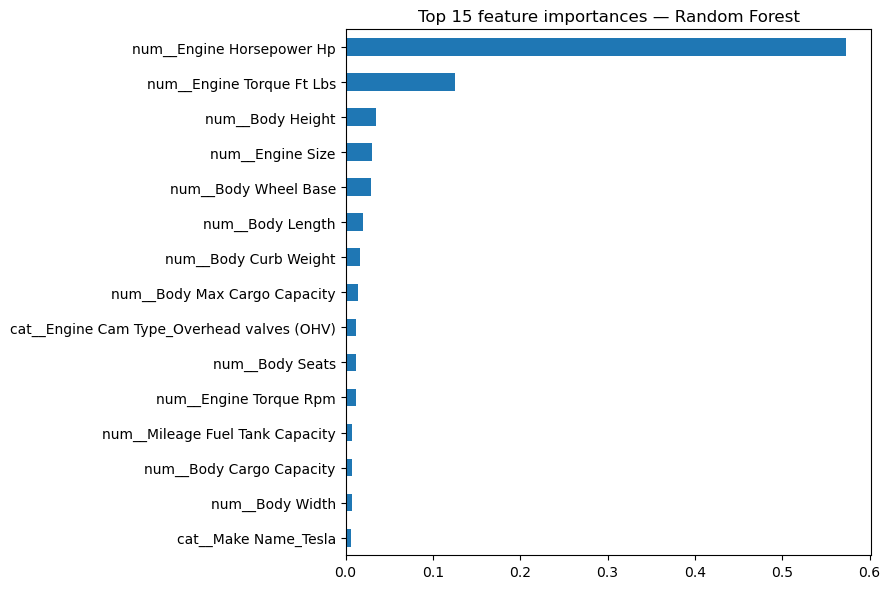

In [ ]:
feat_names  = rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf.named_steps["model"].feature_importances_, index=feat_names)

plt.figure(figsize=(9, 6))
importances.sort_values().tail(15).plot.barh()
plt.title("Top 15 feature importances — Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
X_train_fs = X_train.drop(columns=["Make Name", "Model Name"])
X_test_fs  = X_test.drop(columns=["Make Name", "Model Name"])

num_fs = X_train_fs.select_dtypes(include="number").columns.tolist()
cat_fs = X_train_fs.select_dtypes(include="object").columns.tolist()

preprocess_fs = ColumnTransformer([
    ("num", numeric_pipe, num_fs),
    ("cat", categorical_pipe, cat_fs),
])

rf_fs = Pipeline([("prep", preprocess_fs),
                  ("model", RandomForestRegressor(n_estimators=200,
                                                  random_state=RANDOM_STATE, n_jobs=-1))])
rf_fs.fit(X_train_fs, y_train)
evaluate("RF (no make/model)", y_test, rf_fs.predict(X_test_fs))

pd.DataFrame(results).set_index("Model").round(3)

RF (no make/model)     R2= 0.954  MAE=$2,885  RMSE=$5,270


,R2,MAE,RMSE
Model,,,
Baseline (mean),-0.000,15874.761,24595.646
Linear Regression,0.940,3905.138,6035.616
Random Forest,0.956,2852.281,5132.638
RF (no make/model),0.954,2884.519,5269.878


### Feature engineering: cylinder count
`Engine Cylinders` is stored as text combining layout + count (e.g. "V8", "I4"). We split it
into a numeric `Cylinder Count` (ordinal, so the model sees 4 < 6 < 8) and a categorical
`Engine Config`, replacing 13 opaque one-hot codes with one meaningful number + a small category.

In [ ]:
def add_cylinder_features(X):
    X = X.copy()
    X["Cylinder Count"] = X["Engine Cylinders"].str.extract(r"(\d+)").astype(float)
    X["Engine Config"]  = X["Engine Cylinders"].str.extract(r"([A-Za-z]+)")
    return X.drop(columns=["Engine Cylinders"])

X_train_fe = add_cylinder_features(X_train_fs)   # start from the no-make/model set
X_test_fe  = add_cylinder_features(X_test_fs)

num_fe = X_train_fe.select_dtypes(include="number").columns.tolist()
cat_fe = [c for c in X_train_fe.columns if c not in num_fe]   # robust: catches string dtype too

preprocess_fe = ColumnTransformer([
    ("num", numeric_pipe, num_fe),
    ("cat", categorical_pipe, cat_fe),
])

rf_fe = Pipeline([("prep", preprocess_fe),
                  ("model", RandomForestRegressor(n_estimators=200,
                                                  random_state=RANDOM_STATE, n_jobs=-1))])
rf_fe.fit(X_train_fe, y_train)
evaluate("RF (FE: cylinders)", y_test, rf_fe.predict(X_test_fe))

pd.DataFrame(results).set_index("Model").round(3)

RF (FE: cylinders)     R2= 0.954  MAE=$2,877  RMSE=$5,256


,R2,MAE,RMSE
Model,,,
Baseline (mean),-0.000,15874.761,24595.646
Linear Regression,0.940,3905.138,6035.616
Random Forest,0.956,2852.281,5132.638
RF (no make/model),0.954,2884.519,5269.878
RF (FE: cylinders),0.954,2877.472,5256.019


### Hyperparameter tuning
Tune the chosen Random Forest with RandomizedSearchCV (2 hyperparameters, 3 values each,
3-fold CV). Scoring uses negative MAE — the business-relevant metric. random_state fixes
the search for reproducibility.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

final_rf = Pipeline([("prep", preprocess_fe),
                     ("model", RandomForestRegressor(random_state=RANDOM_STATE))])

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth":    [None, 20, 30],
}

search = RandomizedSearchCV(
    final_rf,
    param_distributions=param_dist,
    n_iter=6,                            # sample 6 of the 9 combinations
    cv=3,
    scoring="neg_mean_absolute_error",   # optimise the dollar error
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_fe, y_train)

print("Best params:", search.best_params_)
print(f"Best CV MAE: ${-search.best_score_:,.0f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'model__n_estimators': 300, 'model__max_depth': 20}
Best CV MAE: $2,992


In [ ]:
best_rf = search.best_estimator_
evaluate("RF (tuned)", y_test, best_rf.predict(X_test_fe))
pd.DataFrame(results).set_index("Model").round(3)

RF (tuned)             R2= 0.954  MAE=$2,889  RMSE=$5,291


,R2,MAE,RMSE
Model,,,
Baseline (mean),-0.000,15874.761,24595.646
Linear Regression,0.940,3905.138,6035.616
Random Forest,0.956,2852.281,5132.638
RF (no make/model),0.954,2884.519,5269.878
RF (FE: cylinders),0.954,2877.472,5256.019
RF (tuned),0.954,2888.783,5291.092


In [ ]:
cv = pd.DataFrame(search.cv_results_)
cv["CV MAE ($)"] = -cv["mean_test_score"]
cv[["param_model__n_estimators", "param_model__max_depth", "CV MAE ($)", "rank_test_score"]] \
    .sort_values("rank_test_score")

,param_model__n_estimators,param_model__max_depth,CV MAE ($),rank_test_score
2,300,20,2991.845405,1
1,200,None,2993.716118,2
5,300,None,2993.761744,3
4,300,30,2993.766604,4
0,200,30,2994.052031,5
3,100,None,3002.362141,6


In [ ]:
# Final chosen model: tuned Random Forest on the engineered, no-make/model feature set
final_model = best_rf

In [ ]:
import joblib
joblib.dump(final_model, "car_price_model.pkl")
print("Saved model to car_price_model.pkl")

Saved model to car_price_model.pkl


# 5. Model Evaluation
Final model: tuned Random Forest on the engineered, no-make/model feature set. We report its
test-set metrics, visualise predicted vs actual price, and demonstrate predictions on new
(unseen) cars — the same logic the Streamlit app will use.

Final model — tuned Random Forest
  R2   : 0.954
  MAE  : $2,889
  RMSE : $5,291


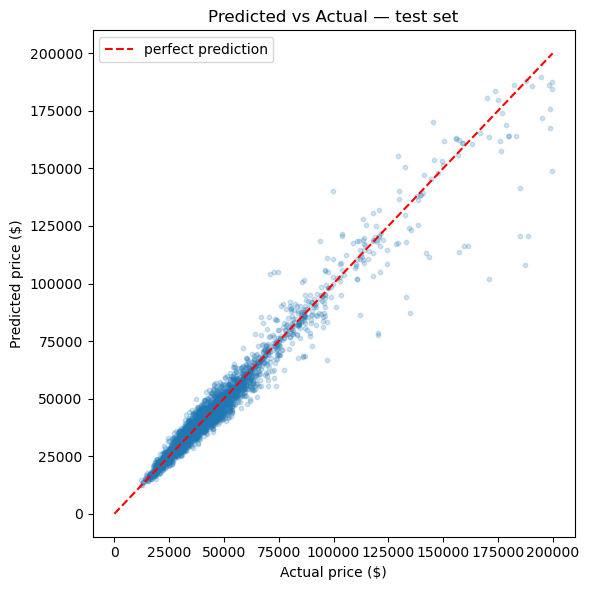

In [ ]:
## Evaluate model — compare models on the test set (R2, MAE, RMSE)
y_pred = final_model.predict(X_test_fe)

print("Final model — tuned Random Forest")
print(f"  R2   : {r2_score(y_test, y_pred):.3f}")
print(f"  MAE  : ${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)
plt.plot([0, 200000], [0, 200000], "r--", label="perfect prediction")
plt.xlabel("Actual price ($)"); plt.ylabel("Predicted price ($)")
plt.title("Predicted vs Actual — test set")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
## New data

## New data
def make_car(**overrides):
    """One car row from typical values; overrides set the key specs,
       unspecified columns fall back to training median/mode."""
    base = {c: (X_train_fe[c].median() if pd.api.types.is_numeric_dtype(X_train_fe[c])
                else X_train_fe[c].mode()[0]) for c in X_train_fe.columns}
    base.update(overrides)
    return pd.DataFrame([base])[X_train_fe.columns]

economy     = make_car(**{"Engine Horsepower Hp": 160, "Engine Torque Ft Lbs": 150,
                          "Cylinder Count": 4, "Engine Config": "I"})
performance = make_car(**{"Engine Horsepower Hp": 450, "Engine Torque Ft Lbs": 430,
                          "Cylinder Count": 8, "Engine Config": "V"})

## Predict
print(f"Economy car (160 hp, I4):     ${final_model.predict(economy)[0]:,.0f}")
print(f"Performance car (450 hp, V8): ${final_model.predict(performance)[0]:,.0f}")

Economy car (160 hp, I4):     $25,072
Performance car (450 hp, V8): $76,731


## Iterative model development

In [ ]:
## Further feature engineering / feature selection
# TODO (next step): e.g. with/without Make & Model experiment, feature importances,
# then hyperparameter tuning of the best model with RandomizedSearchCV.